In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

np.random.seed(2026)

In [26]:
def load_cifar10():
    from tensorflow.keras.datasets import cifar10
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()
    y_train = y_train.reshape(-1)
    y_test = y_test.reshape(-1)
    return x_train, y_train, x_test, y_test

x_train_all, y_train_all, x_test_all, y_test_all = load_cifar10()

class_names_en = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Full Train Data Shape:", x_train_all.shape)
print("Full Test Data Shape:", x_test_all.shape)
print("Number of Classes:", len(class_names_en))

Full Train Data Shape: (50000, 32, 32, 3)
Full Test Data Shape: (10000, 32, 32, 3)
Number of Classes: 10


In [27]:
NUM_TRAIN = 5000
NUM_TEST = 1000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

train_indices = rng.choice(len(x_train_all), size=NUM_TRAIN, replace=False)
test_indices = rng.choice(len(x_test_all), size=NUM_TEST, replace=False)

x_train_small = x_train_all[train_indices]
y_train_small = y_train_all[train_indices]

x_test_small = x_test_all[test_indices]
y_test_small = y_test_all[test_indices]

print(f"Training images used: {x_train_small.shape[0]}")
print(f"Test images used: {x_test_small.shape[0]}")

Training images used: 5000
Test images used: 1000


In [28]:
X_train = x_train_small.reshape(NUM_TRAIN, -1).astype(np.float32)
X_test = x_test_small.reshape(NUM_TEST, -1).astype(np.float32)

y_train = y_train_small.astype(np.int64)
y_test = y_test_small.astype(np.int64)

print("Flattened images to raw pixel features.")
print("Train data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Number of features per image:", X_train.shape[1])

Flattened images to raw pixel features.
Train data shape: (5000, 3072)
Test data shape: (1000, 3072)
Number of features per image: 3072


In [29]:
class KNNClassifier:
    def __init__(self, distance_metric="l2"):
        if distance_metric not in ["l1", "l2"]:
            raise ValueError("distance_metric must be 'l1' or 'l2'.")
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        print(f"{self.distance_metric.upper()} KNN model stored training data.")

    def compute_distances_l2(self, X, test_batch_size=100):
        num_test = X.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.empty((num_test, num_train), dtype=np.float32)
        train_sq = np.sum(self.X_train ** 2, axis=1)

        for start in range(0, num_test, test_batch_size):
            end = min(start + test_batch_size, num_test)
            X_batch = X[start:end]
            test_sq = np.sum(X_batch ** 2, axis=1)
            d2 = test_sq[:, None] + train_sq[None, :] - 2 * X_batch.dot(self.X_train.T)
            d2 = np.maximum(d2, 0)
            dists[start:end] = np.sqrt(d2)

            progress = (end / num_test) * 100
            if progress % 25 == 0:
                print(f"{self.distance_metric.upper()} distance calculation: {progress:.0f}%")

        return dists

    def compute_distances_l1(self, X, test_batch_size=100, train_batch_size=500):
        num_test = X.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.empty((num_test, num_train), dtype=np.float32)

        for test_start in range(0, num_test, test_batch_size):
            test_end = min(test_start + test_batch_size, num_test)
            X_batch = X[test_start:test_end]
            for train_start in range(0, num_train, train_batch_size):
                train_end = min(train_start + train_batch_size, num_train)
                train_batch = self.X_train[train_start:train_end]
                dists[test_start:test_end, train_start:train_end] = np.sum(
                    np.abs(X_batch[:, None, :] - train_batch[None, :, :]), axis=2)

            progress = (test_end / num_test) * 100
            if progress % 25 == 0:
                print(f"{self.distance_metric.upper()} distance calculation: {progress:.0f}%")

        return dists

    def compute_distances(self, X):
        if self.distance_metric == "l1":
            return self.compute_distances_l1(X)
        else:
            return self.compute_distances_l2(X)

    def predict_from_distances(self, dists, k):
        num_test = dists.shape[0]
        y_pred = np.empty(num_test, dtype=np.int64)
        nearest_indices = np.argpartition(dists, kth=k - 1, axis=1)[:, :k]
        nearest_labels = self.y_train[nearest_indices]
        for i in range(num_test):
            vote_count = np.bincount(nearest_labels[i], minlength=10)
            y_pred[i] = np.argmax(vote_count)
        return y_pred

print("KNNClassifier defined.")

KNNClassifier defined.


In [30]:
def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_manual(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label, pred_label] += 1

    return cm

print("Evaluation functions defined.")

Evaluation functions defined.


In [31]:
k_values = [1, 3, 5, 7, 9]
distance_metrics = ["l1", "l2"]

results = []
all_predictions = {}

for metric in distance_metrics:
    print("\n" + "=" * 60)
    print(f"Starting KNN Experiment with {metric.upper()} distance")
    print("=" * 60)

    knn = KNNClassifier(distance_metric=metric)
    knn.fit(X_train, y_train)

    dists = knn.compute_distances(X_test)

    for k in k_values:
        y_pred = knn.predict_from_distances(dists, k)
        acc = accuracy_score_manual(y_test, y_pred)

        results.append({
            "Distance Metric": metric.upper(),
            "K Value": k,
            "Accuracy": acc
        })
        all_predictions[(metric.upper(), k)] = y_pred
        print(f"{metric.upper()}, K={k}: Accuracy = {acc * 100:.2f}%")

print("\nAll experiments completed.")


Starting KNN Experiment with L1 distance
L1 KNN model stored training data.
L1 distance calculation: 50%
L1 distance calculation: 100%
L1, K=1: Accuracy = 28.20%
L1, K=3: Accuracy = 27.30%
L1, K=5: Accuracy = 26.90%
L1, K=7: Accuracy = 27.60%
L1, K=9: Accuracy = 27.80%

Starting KNN Experiment with L2 distance
L2 KNN model stored training data.
L2 distance calculation: 50%
L2 distance calculation: 100%
L2, K=1: Accuracy = 26.60%
L2, K=3: Accuracy = 27.40%
L2, K=5: Accuracy = 27.60%
L2, K=7: Accuracy = 26.70%
L2, K=9: Accuracy = 27.50%

All experiments completed.


In [32]:
result_df = pd.DataFrame(results)
result_df["Accuracy(%)"] = result_df["Accuracy"] * 100

print("KNN Accuracy results by K value and Distance metric:")
display(result_df[["Distance Metric", "K Value", "Accuracy(%)"]])

pivot_df = result_df.pivot(index="K Value", columns="Distance Metric", values="Accuracy(%)")

print("Accuracy Comparison Table:")
display(pivot_df)

KNN Accuracy results by K value and Distance metric:


,Distance Metric,K Value,Accuracy(%)
0,L1,1,28.2
1,L1,3,27.3
2,L1,5,26.9
3,L1,7,27.6
4,L1,9,27.8
5,L2,1,26.6
6,L2,3,27.4
7,L2,5,27.6
8,L2,7,26.7
9,L2,9,27.5


Accuracy Comparison Table:


Distance Metric,L1,L2
K Value,,
1,28.2,26.6
3,27.3,27.4
5,26.9,27.6
7,27.6,26.7
9,27.8,27.5


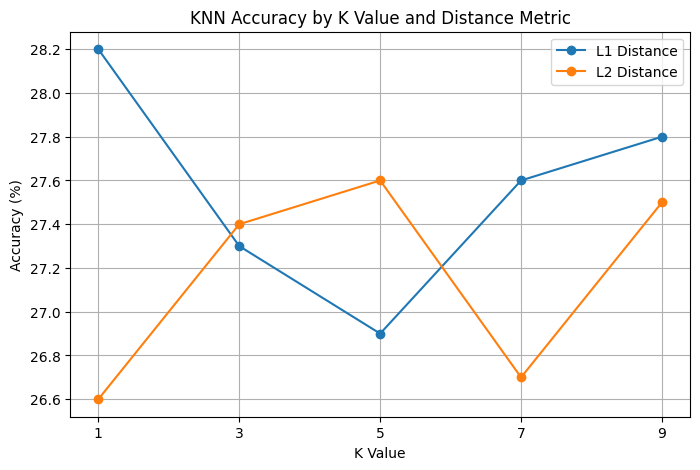

Accuracy plot displayed.


In [33]:
plt.figure(figsize=(8, 5))

for metric in distance_metrics:
    metric_upper = metric.upper()
    subset = result_df[result_df["Distance Metric"] == metric_upper]
    plt.plot(subset["K Value"], subset["Accuracy"] * 100, marker="o", label=f"{metric_upper} Distance")

plt.title("KNN Accuracy by K Value and Distance Metric")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()

print("Accuracy plot displayed.")

Best performing model:
Metric: L1
K: 1
Accuracy: 28.20%
Confusion Matrix Table:


,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
Actual: airplane,34,0,13,4,6,4,2,1,29,0
Actual: automobile,9,18,10,4,5,5,1,3,21,6
Actual: bird,14,0,37,6,27,6,21,2,7,1
Actual: cat,6,2,18,11,12,22,11,5,6,4
Actual: deer,8,0,34,4,31,7,5,4,4,0
Actual: dog,4,1,18,17,16,27,7,5,5,0
Actual: frog,3,0,24,7,27,10,17,2,5,2
Actual: horse,15,1,19,8,14,11,6,27,4,4
Actual: ship,18,4,5,2,8,4,3,3,60,2
Actual: truck,9,5,10,8,10,4,2,6,21,20


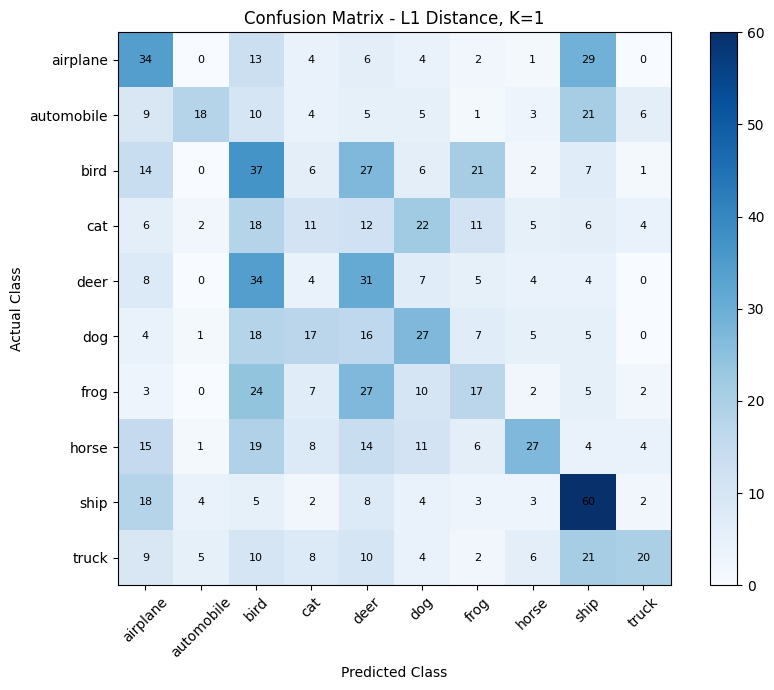

Confusion Matrix visualization completed.


In [34]:
best_row = result_df.loc[result_df["Accuracy"].idxmax()]
best_metric = best_row["Distance Metric"]
best_k = int(best_row["K Value"])
best_accuracy = best_row["Accuracy"]

best_pred = all_predictions[(best_metric, best_k)]
cm = confusion_matrix_manual(y_test, best_pred, num_classes=10)

print("Best performing model:")
print(f"Metric: {best_metric}")
print(f"K: {best_k}")
print(f"Accuracy: {best_accuracy * 100:.2f}%")

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {name}" for name in class_names_en],
    columns=[f"Pred: {name}" for name in class_names_en]
)

print("Confusion Matrix Table:")
display(cm_df)

plt.figure(figsize=(9, 7))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix - {best_metric} Distance, K={best_k}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(range(10), class_names_en, rotation=45)
plt.yticks(range(10), class_names_en)
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("Confusion Matrix visualization completed.")

In [35]:
for metric in ["L1", "L2"]:
    metric_result = result_df[result_df["Distance Metric"] == metric]
    metric_best_row = metric_result.loc[metric_result["Accuracy"].idxmax()]
    metric_best_k = int(metric_best_row["K Value"])
    metric_best_acc = metric_best_row["Accuracy"]

    metric_pred = all_predictions[(metric, metric_best_k)]
    metric_cm = confusion_matrix_manual(y_test, metric_pred, num_classes=10)

    print("\n" + "=" * 60)
    print(f"Best model for {metric} distance")
    print(f"K Value: {metric_best_k}")
    print(f"Accuracy: {metric_best_acc * 100:.2f}%")
    print("=" * 60)

    metric_cm_df = pd.DataFrame(
        metric_cm,
        index=[f"Actual: {name}" for name in class_names_en],
        columns=[f"Pred: {name}" for name in class_names_en]
    )

    display(metric_cm_df)


Best model for L1 distance
K Value: 1
Accuracy: 28.20%


,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
Actual: airplane,34,0,13,4,6,4,2,1,29,0
Actual: automobile,9,18,10,4,5,5,1,3,21,6
Actual: bird,14,0,37,6,27,6,21,2,7,1
Actual: cat,6,2,18,11,12,22,11,5,6,4
Actual: deer,8,0,34,4,31,7,5,4,4,0
Actual: dog,4,1,18,17,16,27,7,5,5,0
Actual: frog,3,0,24,7,27,10,17,2,5,2
Actual: horse,15,1,19,8,14,11,6,27,4,4
Actual: ship,18,4,5,2,8,4,3,3,60,2
Actual: truck,9,5,10,8,10,4,2,6,21,20



Best model for L2 distance
K Value: 5
Accuracy: 27.60%


,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
Actual: airplane,44,0,11,0,4,3,2,1,27,1
Actual: automobile,16,9,17,4,4,5,4,0,23,0
Actual: bird,26,0,50,2,28,6,5,0,4,0
Actual: cat,7,2,32,11,21,8,9,1,5,1
Actual: deer,8,0,50,1,25,5,2,0,6,0
Actual: dog,7,0,29,10,23,20,4,1,6,0
Actual: frog,7,1,42,2,20,2,19,1,3,0
Actual: horse,12,0,26,3,27,6,4,19,10,2
Actual: ship,22,1,4,1,10,1,3,2,65,0
Actual: truck,14,3,14,4,8,2,3,0,33,14


**Limitations of KNN for Image Classification**

KNN has the advantage of being easy to implement. It does not require a separate training process because it simply stores the training data and classifies a new sample by finding its nearest neighbors. However, KNN has significant limitations in image classification tasks such as CIFAR-10.

First, KNN is very slow at test time. For every new image, it must calculate the distance between the test image and all training images. Therefore, as the size of the training dataset increases, the prediction time also increases significantly.

Second, L1 or L2 distance based on raw pixel values does not represent semantic similarity between images very well. Even if two images contain the same object, small changes in position, lighting, background, or occlusion can cause large differences in pixel values.

Third, when a CIFAR-10 image is flattened, one image becomes a 3072-dimensional vector. This can cause the curse of dimensionality. In high-dimensional spaces, distance-based comparisons become less meaningful, and the computational cost also increases.

Fourth, the performance of KNN depends on the value of K and the distance metric. A small K value can be sensitive to noise, while a large K value can make the decision boundary too smooth and may ignore important local differences.

Therefore, KNN can be used as a simple baseline model, but for real image classification tasks, deep learning models such as CNNs are generally more suitable.